In [1]:
import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = fdr.DataReader('NVDA', None)  # 삼성전자
df.tail()

,Open,High,Low,Close,Volume,Adj Close
2026-02-18,188.750000,190.369995,186.759995,187.979996,164749100,187.979996
2026-02-19,187.059998,188.429993,185.660004,187.899994,126554500,187.899994
2026-02-20,186.570007,190.330002,185.940002,189.820007,178422300,189.820007
2026-02-23,191.399994,193.949997,189.580002,191.550003,171584800,191.550003
2026-02-24,191.490005,193.770004,187.399994,192.850006,174595300,192.850006


In [3]:
df = fdr.DataReader('USD/KRW')
df.tail()

,Open,High,Low,Close,Volume,Adj Close
2026-02-19,1449.900024,1452.150024,1443.119995,1440.160034,0.0,1440.160034
2026-02-20,1449.199951,1450.709961,1441.790039,1447.750000,0.0,1447.750000
2026-02-23,1439.949951,1445.250000,1438.369995,1443.439941,0.0,1443.439941
2026-02-24,1443.599976,1446.859985,1437.920044,1442.199951,0.0,1442.199951
2026-02-25,1440.959961,1442.479980,1430.270020,1431.180054,0.0,1431.180054


In [4]:
kospi = fdr.StockListing('KOSPI')
top10 = kospi.nlargest(10, 'Marcap')[['Code', 'Name', 'Marcap']]
print("시가총액 TOP 10")
print(top10)

시가총액 TOP 10
     Code      Name            Marcap
0  005930      삼성전자  1206126226607500
1  000660    SK하이닉스   730519924125000
2  005380       현대차   117326199918000
3  005935     삼성전자우   116194792153600
4  373220  LG에너지솔루션    99333000000000
5  402340     SK스퀘어    86252886095000
6  207940  삼성바이오로직스    79851890475000
7  000270        기아    77262732304200
8  034020   두산에너빌리티    66362134725600
9  105560      KB금융    62825301667500


In [5]:
kospi

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,,203750,1,3750,1.88,202500,206000,201000,17796517,3615386526000,1206126226607500,5919637922,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,,1025000,1,20000,1.99,1012000,1038000,1004000,2274892,2320243561000,730519924125000,712702365,STK
2,005380,KR7005380001,현대차,KOSPI,,573000,1,49000,9.35,535000,579500,532000,3139104,1761596250500,117326199918000,204757766,STK
3,005935,KR7005931001,삼성전자우,KOSPI,,142400,1,1500,1.06,142000,144200,140400,3468281,493038998550,116194792153600,815974664,STK
4,373220,KR7373220003,LG에너지솔루션,KOSPI,,424500,1,12000,2.91,417500,425500,409000,327161,136972384750,99333000000000,234000000,STK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,001525,KR7001521004,동양우,KOSPI,,4745,2,-40,-0.84,4850,4850,4720,6570,31140705,2931133595,617731,STK
946,004415,KR7004411005,서울식품우,KOSPI,,1303,2,-19,-1.44,1316,1359,1303,28557,38153194,2898523500,2224500,STK
947,014915,KR7014911002,성문전자우,KOSPI,,4720,1,95,2.05,4695,4910,4695,13441,65293925,2832000000,600000,STK
948,001527,KR7001522002,동양2우B,KOSPI,,8910,1,60,0.68,8900,8990,8900,133,1184450,2749349790,308569,STK


In [5]:
results = []

for idx, row in top10.iterrows():
    code = row['Code']
    name = row['Name']
    
    try:
        df = fdr.DataReader(code, '2025-01-01')
        
        first_close = df['Close'].iloc[0]
        last_close = df['Close'].iloc[-1]
        return_pct = ((last_close - first_close) / first_close) * 100
        
        results.append({
            '종목코드': code,
            '종목명': name,
            '시가총액': row['Marcap'],
            '2025 수익률(%)': round(return_pct, 2)
        })
    except:
        continue

result_df = pd.DataFrame(results)
print("\n2025년 수익률")
result_df.sort_values('2025 수익률(%)', ascending=False)


2025년 수익률


,종목코드,종목명,시가총액,2025 수익률(%)
6,402340,SK스퀘어,70798693640000,581.93
8,034020,두산에너빌리티,61109533328400,427.13
1,000660,SK하이닉스,632634055185000,404.67
0,005930,삼성전자,984435786428600,211.42
3,005935,삼성전자우,94000281292800,157.49
2,005380,현대차,102788398532000,136.41
9,105560,KB금융,60364488664500,95.32
7,000270,기아,62700327478800,57.58
5,207940,삼성바이오로직스,79481562867000,25.13
4,373220,LG에너지솔루션,91611000000000,12.57


코스피와 달러/원 환율의 상관계수: 0.4509


C:\Users\ajcltm\AppData\Local\Temp\ipykernel_20956\692375973.py:29: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\ajcltm\AppData\Local\Temp\ipykernel_20956\692375973.py:29: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\ajcltm\AppData\Local\Temp\ipykernel_20956\692375973.py:29: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\ajcltm\AppData\Local\Temp\ipykernel_20956\692375973.py:29: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\ajcltm\AppData\Local\Temp\ipykernel_20956\692375973.py:29: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\ajcltm\AppData\Local\Temp\ipykernel_20956\692375973.py:29: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing fro

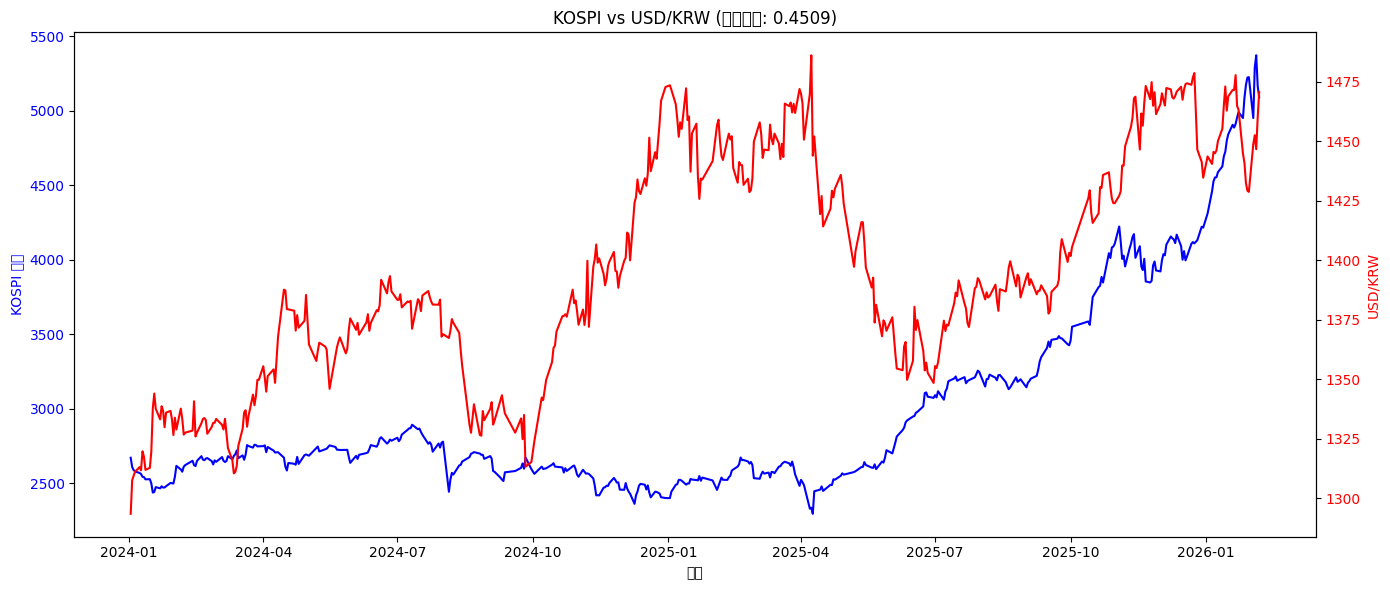

In [ ]:
# 데이터 조회
코스피 = fdr.DataReader('KS11', '2024-01-01')['Close']
달러원 = fdr.DataReader('USD/KRW', '2024-01-01')['Close']

# 데이터 병합 (날짜 기준)
merged = pd.DataFrame({
    'KOSPI': 코스피,
    'USD/KRW': 달러원
}).dropna()

# 상관계수 계산
correlation = merged['KOSPI'].corr(merged['USD/KRW'])
print(f"코스피와 달러/원 환율의 상관계수: {correlation:.4f}")

# 시각화
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel('날짜')
ax1.set_ylabel('KOSPI 지수', color='blue')
ax1.plot(merged.index, merged['KOSPI'], color='blue', label='KOSPI')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('USD/KRW', color='red')
ax2.plot(merged.index, merged['USD/KRW'], color='red', label='USD/KRW')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'KOSPI vs USD/KRW (상관계수: {correlation:.4f})')
fig.tight_layout()
plt.show()

,시가,고가,저가,종가,거래량,거래대금,등락률,시가총액
티커,,,,,,,,
095570,4845,4900,4805,4895,138511,669906000,0.820000,221512255305
006840,17610,17750,17000,17390,18472,319923540,-1.190000,230375085790
027410,4080,4200,4060,4155,359399,1489311920,1.960000,397703266605
282330,134400,135100,133000,133000,41395,5540071500,-0.080000,2298759498000
138930,7880,7980,7770,7810,1659665,13060071440,-0.130000,2515510700780
...,...,...,...,...,...,...,...,...
079980,4000,4025,3975,4005,55958,223733385,0.130000,138172500000
005010,5750,5990,5600,5870,1692131,9789226490,4.260000,329824000250
000540,5280,5280,5280,5280,938906,4957423680,29.889999,339201165600
